# ALICE nuclear modification across probes

65 curated measurement curves from the **default SciPaperlib** library. This notebook uses the bundled numeric tables with Matplotlib and offers an `ipywidgets` selector. Run all cells, then choose a preset or individual measurements. The companion HTML works offline without Python.

Central A–A $R_{AA}$, centrality-selected p–Pb $Q_{pPb}$ and minimum-bias $R_{pA}$ are kept distinct. The lowest published percentile bin differs by analysis. The oxygen data are minimum bias. See `README.md` and `SOURCES.md` for definitions and caveats.

## Setup

Open this notebook from the extracted folder, keeping `raa_plot.py` and `data/` beside it. Install dependencies in your selected kernel if needed:
```python
%pip install matplotlib numpy ipywidgets
```
The original YAML is only needed for independent validation; plotting reads the bundled JSON.

In [1]:
%matplotlib inline
from pathlib import Path
import json, hashlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from raa_plot import load_data, plot_selected

data = load_data()
by_key = {c["key"]: c for c in data["curves"]}
print(f"{len(by_key)} curves; {sum(len(c["points"]) for c in by_key.values())} points")

65 curves; 1315 points


## Overview

All four panels below use 5.02 TeV data. Statistical bars and point-dependent systematic boxes are shown; separately deposited global scale errors are retained in the data but not drawn. **† D⁰-tagged jet statistical errors appear unusually small in the deposited table and are preserved without correction.**

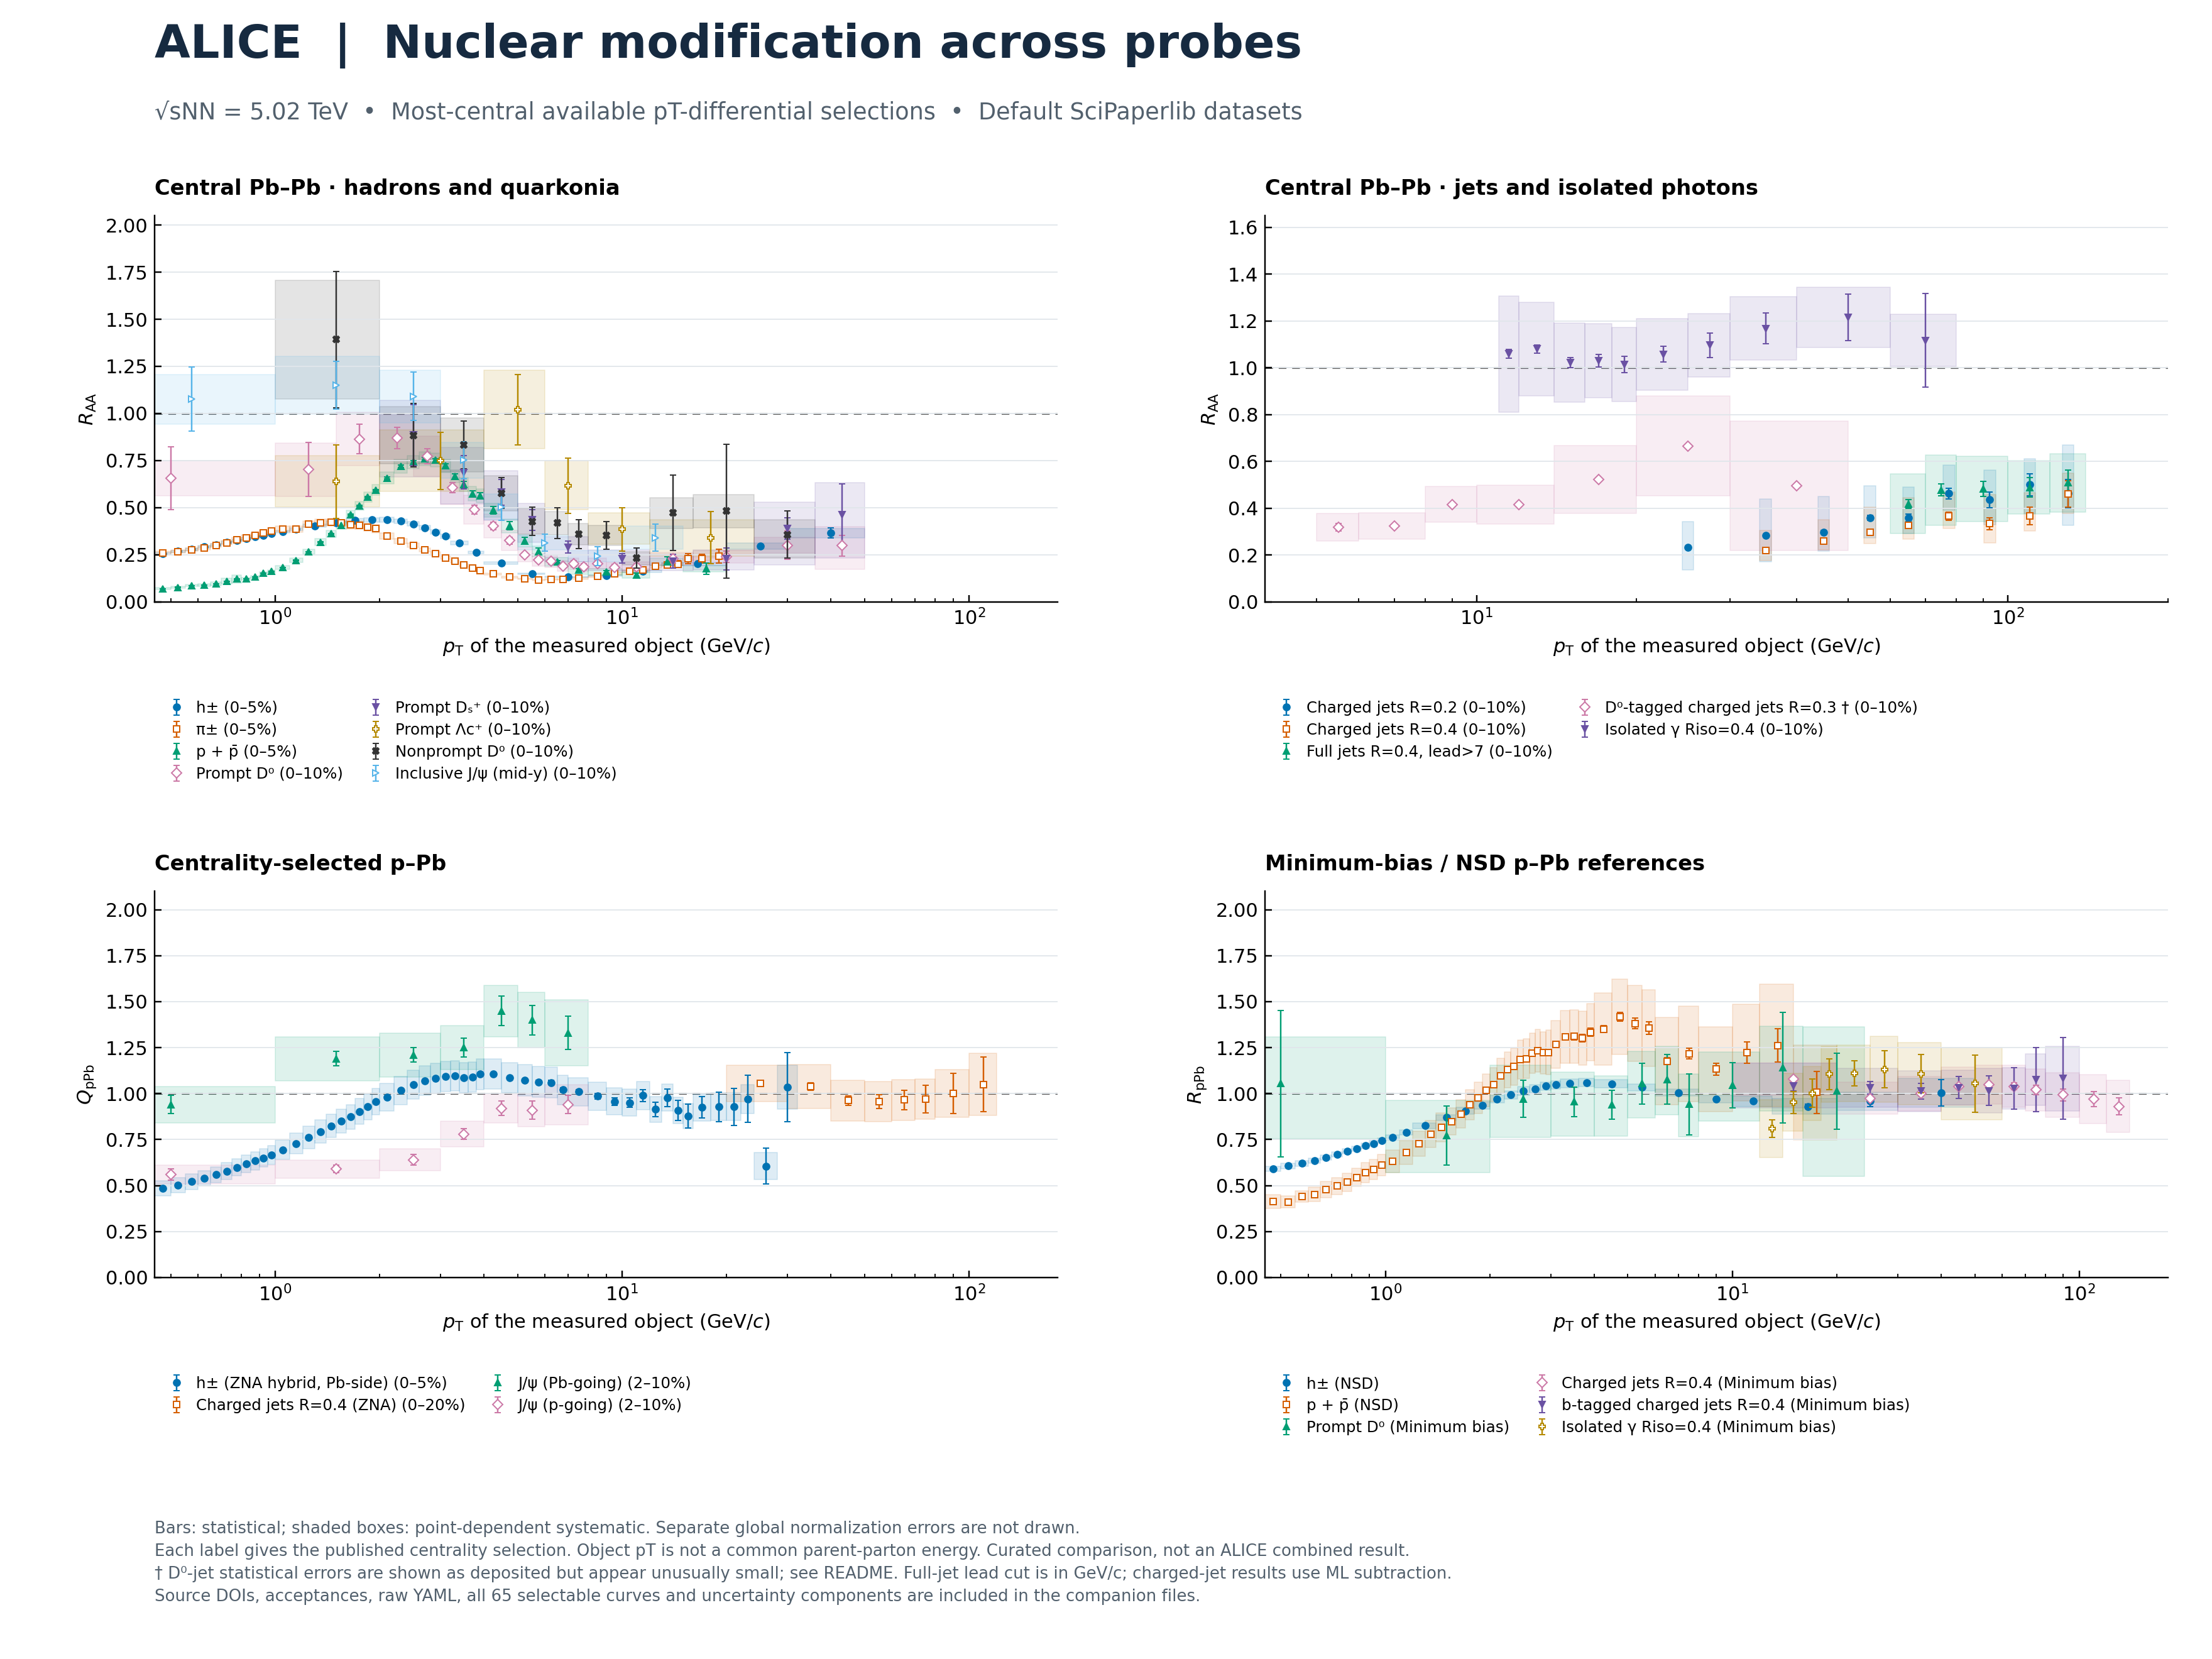

In [2]:
from IPython.display import Image
display(Image(filename="alice_raa_summary.png"))

## Select what is plotted

Use Ctrl/Cmd-click to select multiple individual curves. Different observable definitions automatically get separate panels. Sources for the selection appear below the plot. A momentum cut changes the displayed range only; no points are rebinned.

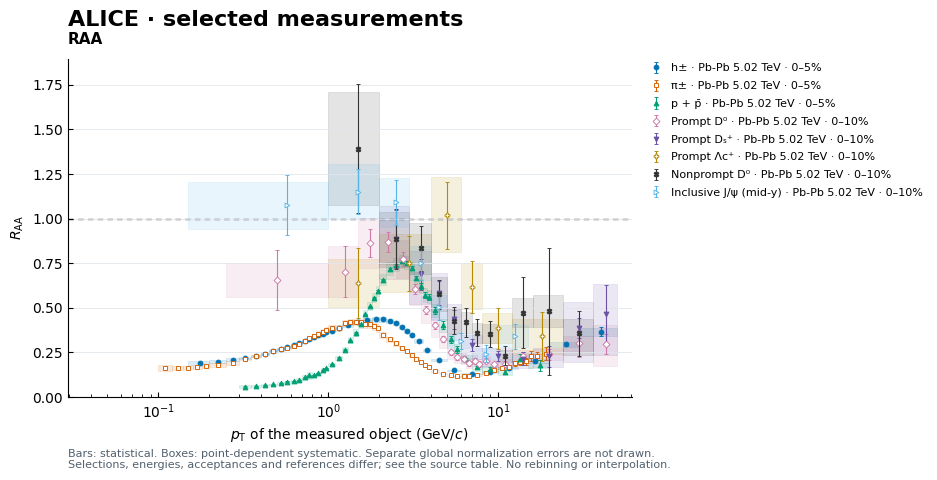

In [3]:
preset = widgets.Dropdown(options=list(data["presets"]), description="Preset:", layout=widgets.Layout(width="700px"))
selected = widgets.SelectMultiple(options=[(c["label"],c["key"]) for c in data["curves"]], value=tuple(next(iter(data["presets"].values()))), description="Curves:", rows=13, layout=widgets.Layout(width="98%"))
logx = widgets.Checkbox(value=True, description="Log pT")
systematics = widgets.Checkbox(value=True, description="Systematic boxes")
output = widgets.Output()

def update_plot(change=None):
    with output:
        clear_output(wait=True)
        fig = plot_selected(selected.value, logx=logx.value, systematics=systematics.value)
        display(fig)
        plt.close(fig)
        import html
        items=[]
        for key in selected.value:
            c=by_key[key]
            items.append(f'<li><b>{html.escape(c["label"])}</b><br>{html.escape(c["acceptance"])}<br><a href="{c["source_url"]}">{c["table_doi"]}</a> — {html.escape(c["source"]["table"])}<br>{html.escape(c["notes"])}</li>')
        display(HTML("<ul>"+"".join(items)+"</ul>"))

def use_preset(change):
    selected.value=tuple(data["presets"][change["new"]])

preset.observe(use_preset, names="value")
for control in [selected,logx,systematics]:
    control.observe(update_plot,names="value")
display(widgets.VBox([preset,selected,widgets.HBox([logx,systematics]),output]))
update_plot()

## Export the current selection

Run this cell again after changing the controls. PNG and SVG use Matplotlib. The JSON includes the original numeric strings, bin edges, all uncertainty components, qualifiers and source DOIs.

In [4]:
fig = plot_selected(selected.value, logx=logx.value, systematics=systematics.value)
fig.savefig("alice_selected.png", dpi=220, bbox_inches="tight")
fig.savefig("alice_selected.svg", bbox_inches="tight")
plt.close(fig)
Path("alice_selected.json").write_text(json.dumps({**data,"curves":[by_key[k] for k in selected.value]}, ensure_ascii=False, indent=2))
print("Saved alice_selected.png, alice_selected.svg, alice_selected.json")

Saved alice_selected.png, alice_selected.svg, alice_selected.json


## Inspect a measurement and validate the bundled source files

The following checks every included YAML file against the library checksum, verifies the original central values, and prints one deposited point with its complete error breakdown. Missing cells (`-`) are logged in `data/validation.json`; they are not converted to zero.

In [5]:
for c in data["curves"]:
    assert hashlib.sha256(Path(c["raw_file"]).read_bytes()).hexdigest() == c["sha256"]
    for p in c["points"]:
        assert p["y"] == float(p["original_y"]["value"])
print("All bundled file checksums and original central values verified.")
example=by_key["pb_d0"]
print(example["source_url"])
print(json.dumps(example["points"][0], ensure_ascii=False, indent=2))

All bundled file checksums and original central values verified.
https://doi.org/10.17182/hepdata.127979.v1/t11
{
  "x": 0.5,
  "xlow": 0.0,
  "xhigh": 1.0,
  "y": 0.656009,
  "source_row": 0,
  "errors": [
    {
      "label": "stat.",
      "kind": "stat",
      "minus": 0.16724,
      "plus": 0.16724,
      "original": {
        "label": "stat.",
        "symerror": "0.16724"
      }
    },
    {
      "label": "syst.",
      "kind": "sys",
      "minus": 0.0943014,
      "plus": 0.0943067,
      "original": {
        "label": "syst.",
        "asymerror": {
          "minus": "-0.0943014",
          "plus": "0.0943067"
        }
      }
    },
    {
      "label": "syst. global normalization uncertainty",
      "kind": "global",
      "minus": 0.017083523974399998,
      "plus": 0.017083523974399998,
      "original": {
        "label": "syst. global normalization uncertainty",
        "symerror": "2.60416%"
      }
    }
  ],
  "stat_minus": 0.16724,
  "stat_plus": 0.16724,
  "sys

## Interpretation limits

- This is a curated comparison, not an ALICE combined result or a complete library census.
- Energies, rapidities, centralities, jet radii, leading-track cuts and reference constructions differ. A hadron and a jet at equal pT do not select equal parent-parton energies.
- p–Pb $Q_{pPb}$ depends on the event-activity estimator and the nuclear-scaling procedure; minimum-bias/NSD $R_{pPb}$ is kept separate. [ALICE centrality-method paper](https://arxiv.org/abs/1412.6828).
- Percentage errors are converted to absolute errors on the ordinate. Supplied total systematics are preferred; otherwise named point-dependent terms are combined in quadrature for display only. Cross-bin and cross-measurement correlations are not reconstructed.
- Separate scale errors are preserved but not drawn, including the correlated pT-global terms in the selected J/ψ QpPb tables. Additional scale errors appearing only in descriptions/paper text are not numerically reconstructed.
- Horizontal boxes use source bin edges. If a table supplies only pT centres, narrow decorative box widths are used.
- The D⁰-jet deposited statistical errors should be checked with the original authors before any significance estimate. No corrections have been invented.